In [81]:
from koala.lattice import Lattice
import numpy as np
import numpy.typing as npt
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.flux_finder import ujk_from_fluxes, fluxes_from_ujk
from koala import plotting as pl

from pfapack.ctypes import pfaffian
import pfapack.ctypes as cpf
import ctypes
from scipy import linalg as la
from matplotlib import pyplot as plt
from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import kasteleyn_matrix, _fast_pfaffian

In [82]:
def k_ham_generator(lattice, hamiltonian):
    """
    Adds momentum dependence to a given lattice and Hamiltonian.

    Parameters:
    - lattice: An instance of Lattice.
    - hamiltonian: A function that takes a pair of vertices and returns the weight of the edge between them.

    Returns:
    - A momentum-dependent matrix for the lattice.
    """

    def k_hamiltonian(k: np.ndarray):

        # k = np.asarray(k, dtype=np.complex128)
        cross = lattice.edges.crossing
        phases = np.sum(cross * k, axis=-1)

        h = np.array(hamiltonian, dtype=np.complex128)
        h[lattice.edges.indices[:, 1], lattice.edges.indices[:, 0]] *= np.exp(
            1j * phases
        )
        h[lattice.edges.indices[:, 0], lattice.edges.indices[:, 1]] *= np.exp(
            -1j * phases
        )

        return h

    return k_hamiltonian

total is: 49
total is: 7.0
Nex, Nox is: 29.0 -20.0
Ney, Noy is: 7.0 2.0
Nex/Nox is: -0.689655
Ney/Noy is:  0.285714


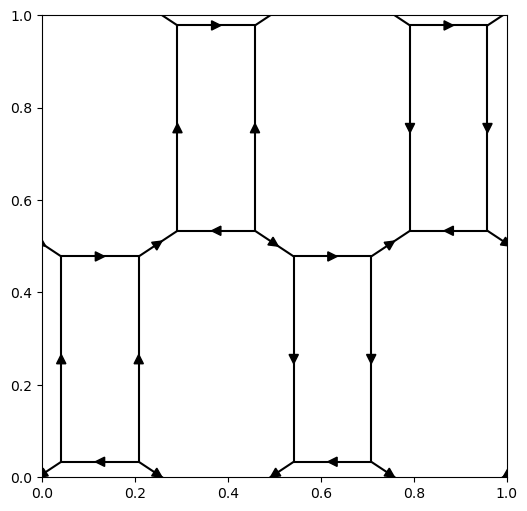

In [ ]:
from dimer_models.kasteleyn import find_kasteleyn_number


# mini_lattice = eg.hex_square_oct_lattice(10)
mini_lattice.compact_rep

# shift = np.array([0.0.1, 0.01])
# data = mini_lattice.compact_rep
# for vertex in range(mini_lattice.n_vertices):
#     data = gu.shift_vertex((*data,mini_lattice.vertices.adjacent_edges), vertex, shift)
# mini_lattice = Lattice(*data)

mini_lattice = eg.honeycomb_lattice(2)

# kitaev edge labels
edge_angles = np.arctan2(*mini_lattice.edges.vectors.T) % np.pi
_, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)
mask = edge_labels == 0
mini_lattice = expand_edges_to_squares(mini_lattice, np.where(mask)[0])


orientation = ujk_from_fluxes(mini_lattice, [-1] * mini_lattice.n_plaquettes)
orientationfluxes = fluxes_from_ujk(mini_lattice, orientation)

kast = k_ham_generator(mini_lattice, kasteleyn_matrix(mini_lattice, orientation))
# n_dimers = gu.dimerise(mini_lattice, -1).shape[0]

print(f"total is: {find_kasteleyn_number(mini_lattice)}")

fig = plt.figure(figsize=(6, 6))
pl.plot_edges(
    mini_lattice,
    directions=orientation,
)
# plt.show()

four_sectors = [kast([0, 0]), kast([0, np.pi]), kast([np.pi, 0]), kast([np.pi, np.pi])]

nk = np.zeros(4)
powk = np.zeros(4)
for i, k in enumerate(four_sectors):
    pf = _fast_pfaffian(k.real)
    nk[i] = pf[0]
    powk[i] = pf[1]


Nex = (nk[2] * 10 ** powk[2] + nk[3] * 10 ** powk[3]) // 2
Nox = (-nk[0] * 10 ** powk[0] + nk[1] * 10 ** powk[1]) // 2
Ney = (nk[1] * 10 ** powk[1] + nk[3] * 10 ** powk[3]) // 2
Noy = (-nk[0] * 10 ** powk[0] + nk[2] * 10 ** powk[2]) // 2

print(f"total is: {(- nk[0] + nk[1]+ nk[2]+ nk[3])//2}")
print(f"Nex, Nox is: {Nex} {Nox}")
print(f"Ney, Noy is: {Ney} {Noy}")
print(f"Nex/Nox is: {Nox / Nex: 5f}")
print(f"Ney/Noy is: {Noy / Ney: 5f}")

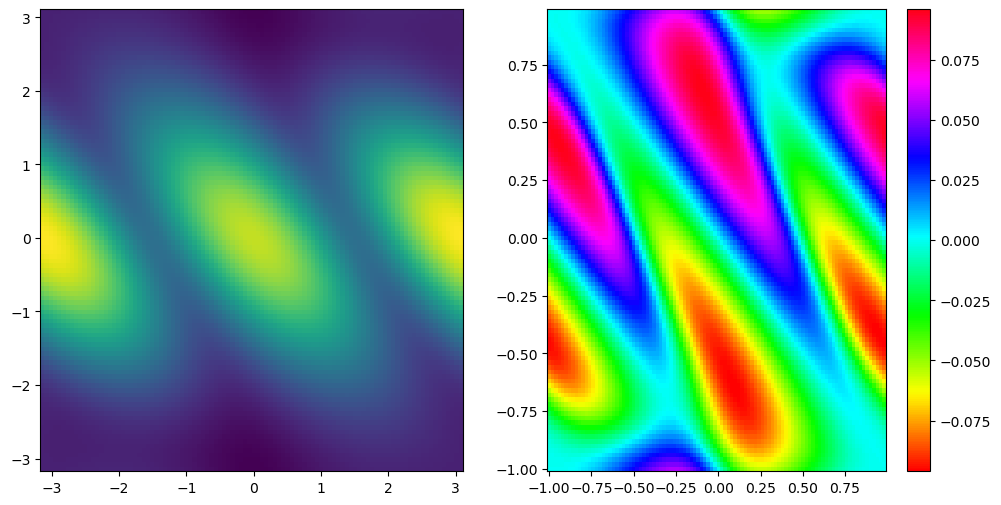

In [ ]:
k_vals = np.linspace(-np.pi, np.pi, 100, endpoint=False)
KX, KY = np.meshgrid(k_vals, k_vals)

pfafs = np.zeros(KX.shape, dtype=np.complex128)
eigs = np.zeros(KX.shape, dtype=np.complex128)

for kx, ky in zip(KX.flatten(), KY.flatten()):
    k = kast([kx, ky])
    pfafs[np.where((KX == kx) & (KY == ky))] = pfaffian(k)
    # print(la.eigvalsh(k))
    # eigs[np.where((KX == kx) & (KY == ky))] = la.eigvals(k)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].pcolormesh(KX, KY, np.abs(pfafs))
x = ax[1].pcolormesh(KX / np.pi, KY / np.pi, np.angle(pfafs) / (2 * np.pi), cmap="hsv")
plt.colorbar(x)
plt.show()